In [11]:
import ROOT
from ROOT import TFile, TTree, TH1F, TCanvas
import sys
import numpy as np
from array import array
%jsroot off 
# ^ forces static rendering of histograms in the notebook, otherwise they will be rendered as interactive JS objects which do not display properly in the notebook.


In [2]:
f = ROOT.TFile.Open("/data2/segmentlinking/CMSSW_12_5_0_pre3/RelValTTbar_14TeV_CMSSW_12_5_0_pre3/event_1000.root")
dir = f.Get("trackingNtuple")
t = dir.Get("tree")
t.Print()

******************************************************************************
*Tree    :tree      : tree                                                   *
*Entries :     1000 : Total =    372845568948 bytes  File  Size = 151229513879 *
*        :          : Tree compression factor =   2.47                       *
******************************************************************************
*Br    0 :event     : event/l                                                *
*Entries :     1000 : Total  Size=     100313 bytes  File Size  =      80000 *
*Baskets :     1000 : Basket Size=        894 bytes  Compression=   1.00     *
*............................................................................*
*Br    1 :lumi      : lumi/i                                                 *
*Entries :     1000 : Total  Size=      95301 bytes  File Size  =      75000 *
*Baskets :     1000 : Basket Size=        894 bytes  Compression=   1.00     *
*.................................................

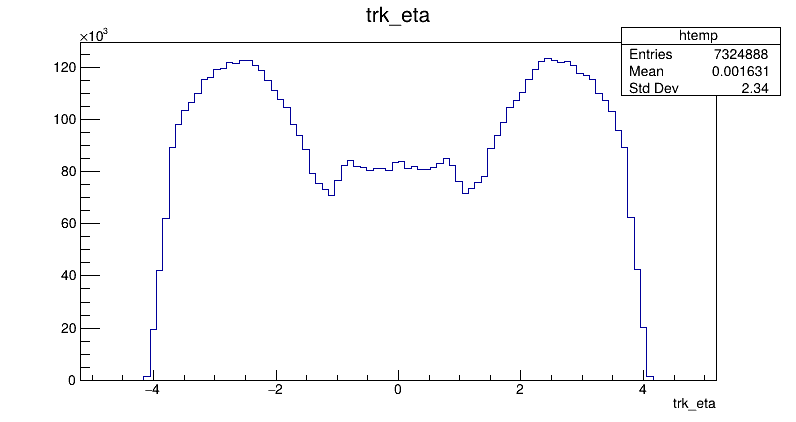

In [3]:
canvas = TCanvas("canvas", "2", 800, 450)
t.Draw("trk_eta")
#t.Draw("trk_phi")
canvas.Draw()

In [8]:
import numpy as np

ACCEPT_RATIO = 0.75

match_frac = []
fake_rate  = []
event_id   = []

for event in t:

    trk_pt     = event.trk_pt
    j          = event.trk_bestSimTrkIdx
    share_frac = event.trk_bestSimTrkShareFrac

    N_reco = trk_pt.size()
    if N_reco == 0:
        match_frac.append(0.0)
        fake_rate.append(0.0)
        event_id.append(event.event)
        continue

    N_matched = sum(
        (j[i] >= 0 and share_frac[i] >= ACCEPT_RATIO)
        for i in range(N_reco)
    )

    frac = N_matched / N_reco
    match_frac.append(frac)
    fake_rate.append(1.0 - frac)
    event_id.append(event.event)
    print(f"Event {event.event}: match fraction = {frac:.2f}, fake rate = {1.0 - frac:.2f}")

# convert to numpy arrays
match_frac = np.array(match_frac)
fake_rate  = np.array(fake_rate)
event_id   = np.array(event_id)

np.savez(
    "mapping_sanity_cache.npz",
    match_frac=match_frac,
    fake_rate=fake_rate,
    event_id=event_id
)

print("Saved locally to mapping_sanity_cache.npz")

Event 7402: match fraction = 0.91, fake rate = 0.09
Event 7421: match fraction = 0.92, fake rate = 0.08
Event 7420: match fraction = 0.91, fake rate = 0.09
Event 7422: match fraction = 0.92, fake rate = 0.08
Event 7403: match fraction = 0.94, fake rate = 0.06
Event 7408: match fraction = 0.90, fake rate = 0.10
Event 7410: match fraction = 0.92, fake rate = 0.08
Event 7401: match fraction = 0.91, fake rate = 0.09
Event 7423: match fraction = 0.90, fake rate = 0.10
Event 7424: match fraction = 0.91, fake rate = 0.09
Event 7433: match fraction = 0.91, fake rate = 0.09
Event 7405: match fraction = 0.93, fake rate = 0.07
Event 7406: match fraction = 0.91, fake rate = 0.09
Event 7404: match fraction = 0.88, fake rate = 0.12
Event 7427: match fraction = 0.92, fake rate = 0.08
Event 7425: match fraction = 0.91, fake rate = 0.09
Event 7407: match fraction = 0.93, fake rate = 0.07
Event 7429: match fraction = 0.94, fake rate = 0.06
Event 7428: match fraction = 0.89, fake rate = 0.11
Event 7411: 

In [9]:
# loading data if it previously exists

data = np.load("mapping_sanity_cache.npz")

match_frac = data["match_frac"]
fake_rate  = data["fake_rate"]
event_id   = data["event_id"]

print("Loaded from cache ?")

print(match_frac[975:])

Loaded from cache ?
[0.92135698 0.92472173 0.91075022 0.90075512 0.89190125 0.91367307
 0.90294722 0.88921619 0.91073415 0.91925553 0.89478045 0.92067583
 0.92202933 0.92980418 0.89400693 0.89962374 0.9193787  0.92398022
 0.91561181 0.94506518 0.88785273 0.91838291 0.90636178 0.92767793
 0.89231541]


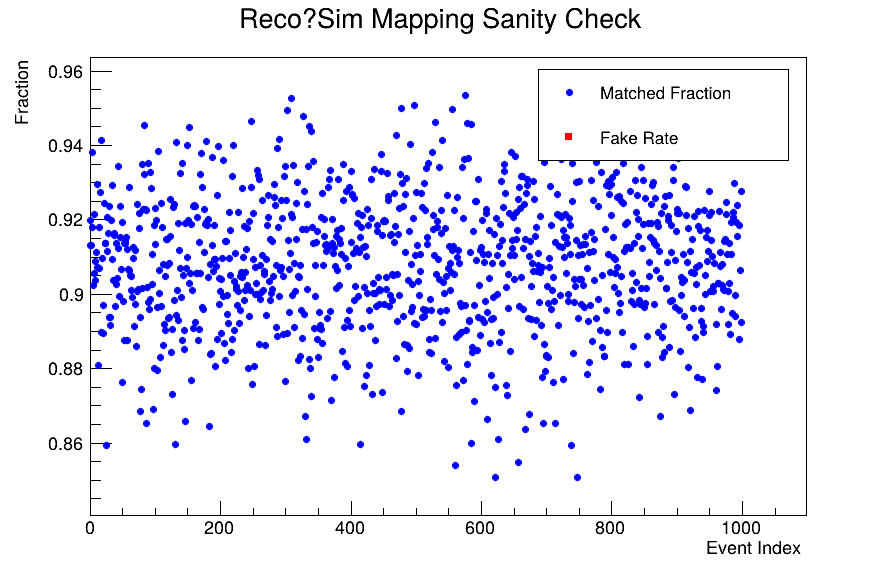

In [12]:
n = len(match_frac)

# --- Create graphs ---
g_match = ROOT.TGraph()
g_fake  = ROOT.TGraph()

for i in range(n):
    g_match.SetPoint(i, i, float(match_frac[i]))
    g_fake.SetPoint(i, i, float(fake_rate[i]))

# --- Style ---
g_match.SetTitle("Reco?Sim Mapping Sanity Check;Event Index;Fraction")
g_match.SetMarkerStyle(20)
g_match.SetMarkerColor(ROOT.kBlue)
g_match.SetMarkerSize(0.9)

g_fake.SetMarkerStyle(21)
g_fake.SetMarkerColor(ROOT.kRed)
g_fake.SetMarkerSize(0.9)

# --- Draw ---
c = ROOT.TCanvas("c", "Match Fraction vs Fake Rate", 900, 600)
g_match.Draw("AP")
g_fake.Draw("P SAME")

leg = ROOT.TLegend(0.60, 0.72, 0.88, 0.88)
leg.AddEntry(g_match, "Matched Fraction", "p")
leg.AddEntry(g_fake,  "Fake Rate", "p")
leg.Draw()

c.Draw()